In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [75]:
df=pd.read_csv(r"C:\Users\Vishnuraj\Downloads\taxi_trip_pricing.csv")
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [76]:
df.columns

Index(['Trip_Distance_km', 'Time_of_Day', 'Day_of_Week', 'Passenger_Count',
       'Traffic_Conditions', 'Weather', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price'],
      dtype='str')

In [78]:
df=df.drop(['Base_Fare','Per_Minute_Rate'],axis=1)

### Handling null values

In [79]:
df.isna().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Per_Km_Rate              50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [80]:
df = df.dropna(subset=['Trip_Price'])

In [81]:
df.isna().sum()

Trip_Distance_km         50
Time_of_Day              49
Day_of_Week              46
Passenger_Count          48
Traffic_Conditions       50
Weather                  46
Per_Km_Rate              44
Trip_Duration_Minutes    46
Trip_Price                0
dtype: int64

In [82]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
df[['Trip_Distance_km','Per_Km_Rate','Trip_Duration_Minutes']]= imputer.fit_transform(df[['Trip_Distance_km','Per_Km_Rate','Trip_Duration_Minutes']])

In [83]:
imputer2=SimpleImputer(strategy='most_frequent')
df[['Time_of_Day','Day_of_Week','Traffic_Conditions','Weather']]= imputer2.fit_transform(df[['Time_of_Day','Day_of_Week','Traffic_Conditions','Weather']])

In [84]:
df['Passenger_Count']=df['Passenger_Count'].fillna(df['Passenger_Count'].median())

In [85]:
df.isna().sum()

Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Per_Km_Rate              0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64

In [86]:
df.dtypes

Trip_Distance_km         float64
Time_of_Day                  str
Day_of_Week                  str
Passenger_Count          float64
Traffic_Conditions           str
Weather                      str
Per_Km_Rate              float64
Trip_Duration_Minutes    float64
Trip_Price               float64
dtype: object

### Checking outliers

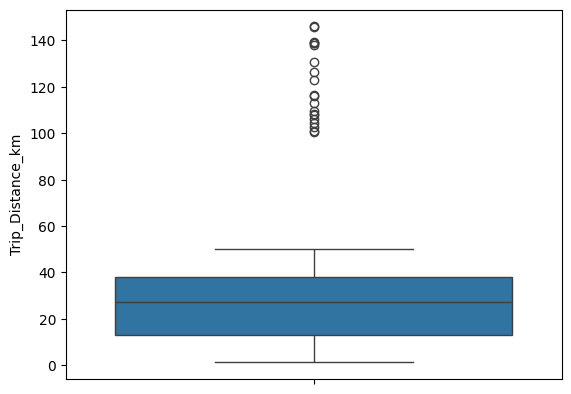

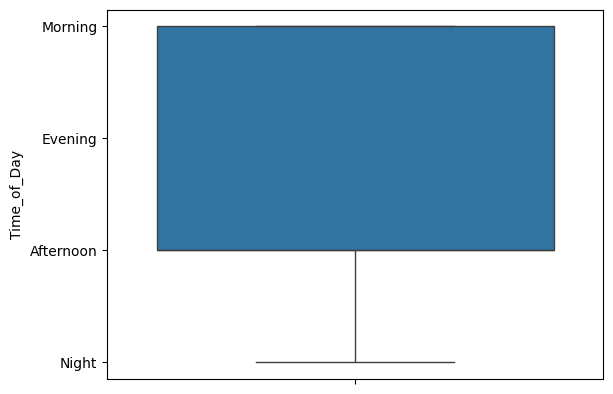

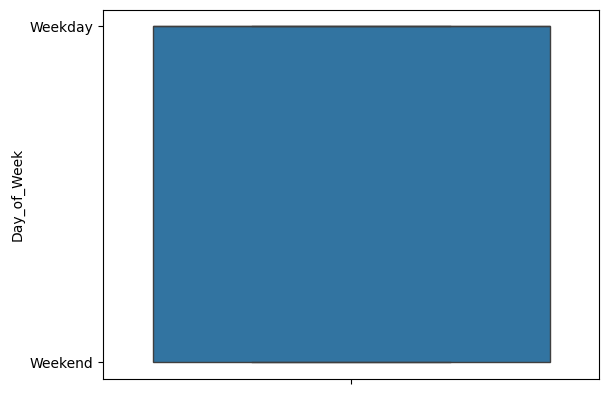

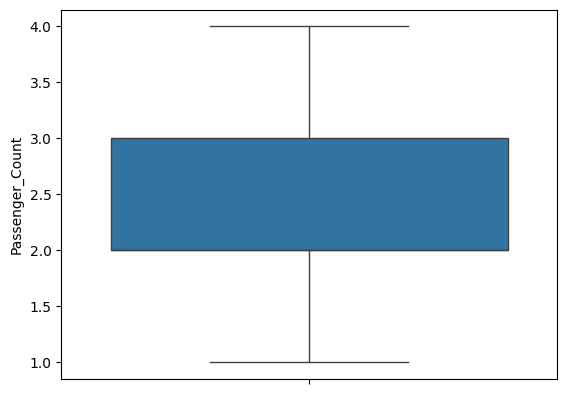

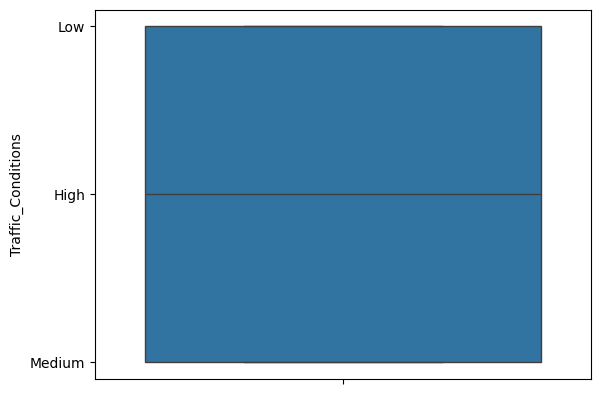

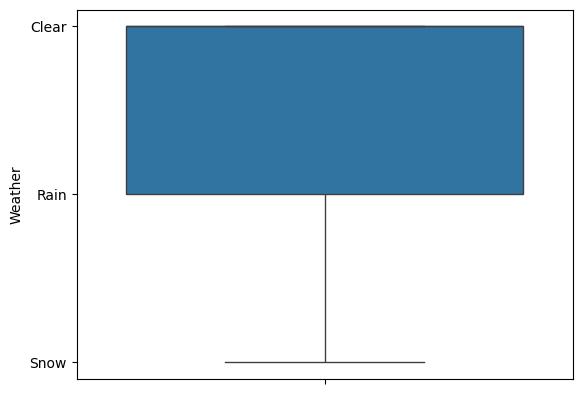

KeyError: 'Base_Fare'

In [87]:
li=['Trip_Distance_km','Time_of_Day','Day_of_Week','Passenger_Count','Traffic_Conditions','Weather','Base_Fare','Per_Km_Rate','Per_Minute_Rate',
'Trip_Duration_Minutes','Trip_Price']
for i in li:
    sns.boxplot(df[i])
    plt.show()

### Distribution of Trip Price

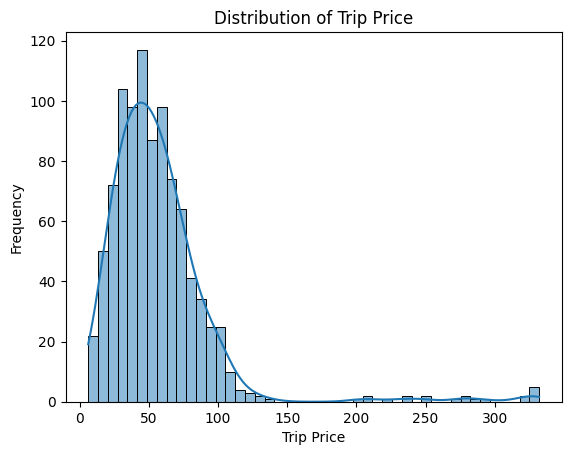

In [88]:
sns.histplot(df['Trip_Price'], kde=True)
plt.title("Distribution of Trip Price")
plt.xlabel("Trip Price")
plt.ylabel("Frequency")
plt.show()

### Distance vs Price

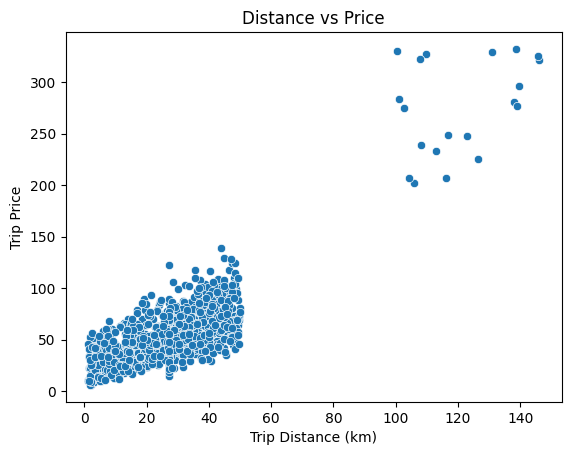

In [89]:
sns.scatterplot(x='Trip_Distance_km', y='Trip_Price', data=df)
plt.title("Distance vs Price")
plt.xlabel("Trip Distance (km)")
plt.ylabel("Trip Price")
plt.show()

### Time of Day vs Price

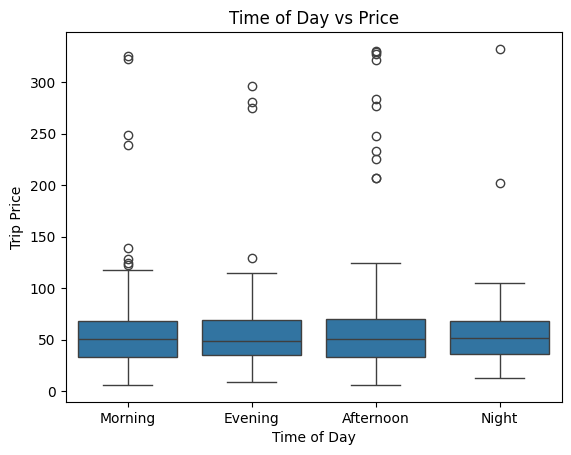

In [90]:
sns.boxplot(x='Time_of_Day', y='Trip_Price', data=df)
plt.title("Time of Day vs Price")
plt.xlabel("Time of Day")
plt.ylabel("Trip Price")
plt.show()

### Weather vs Trip Price

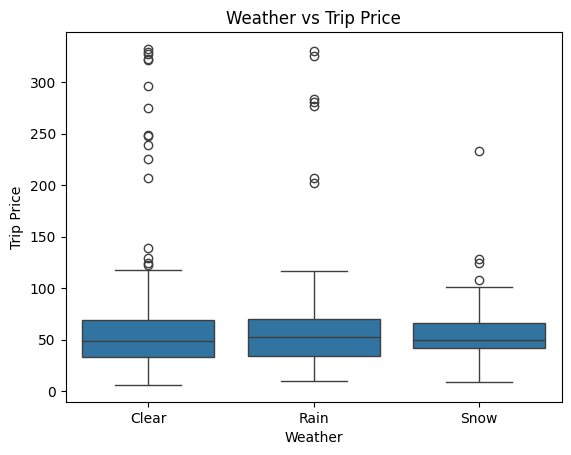

In [91]:
sns.boxplot(x='Weather', y='Trip_Price', data=df)
plt.title("Weather vs Trip Price")
plt.xlabel("Weather")
plt.ylabel("Trip Price")
plt.show()

### Passengers vs Price

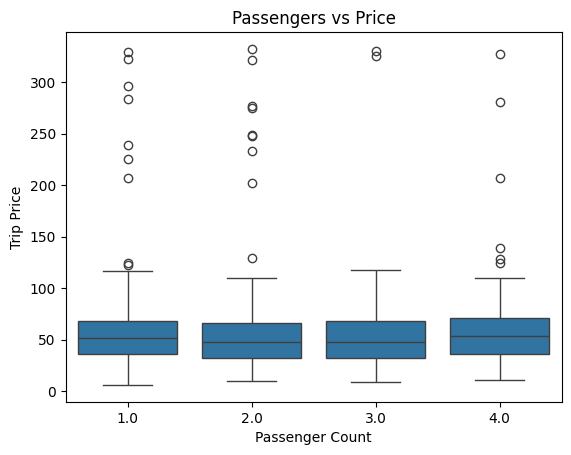

In [92]:
sns.boxplot(x='Passenger_Count', y='Trip_Price', data=df)
plt.title("Passengers vs Price")
plt.xlabel("Passenger Count")
plt.ylabel("Trip Price")
plt.show()

### Correlation Heatmap

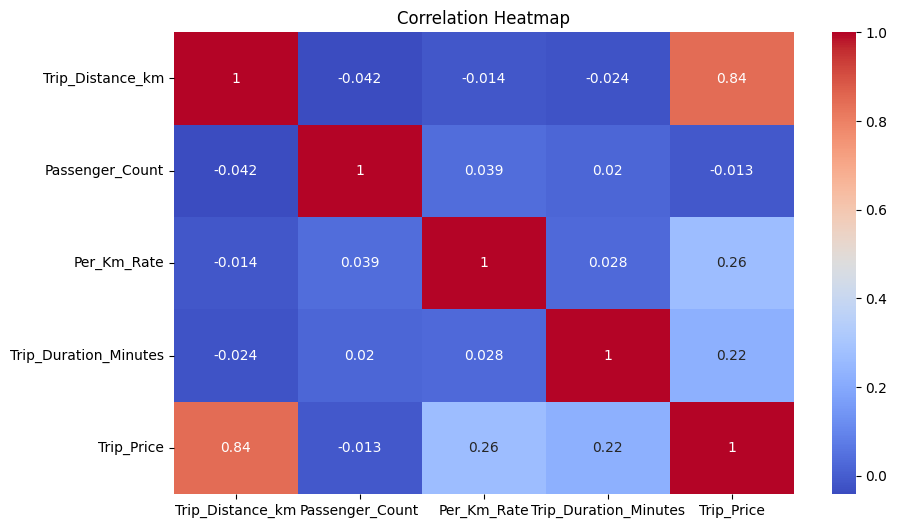

In [93]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Encoding

In [94]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Per_Km_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,Morning,Weekday,3.0,Low,Clear,0.80,53.82,36.2624
2,36.870000,Evening,Weekend,1.0,High,Clear,1.21,37.27,52.9032
3,30.330000,Evening,Weekday,4.0,Low,Clear,0.51,116.81,36.4698
4,27.190998,Evening,Weekday,3.0,High,Clear,0.63,22.64,15.6180
5,8.640000,Afternoon,Weekend,2.0,Medium,Clear,1.71,89.33,60.2028


In [95]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Time_of_Day'] = le.fit_transform(df['Time_of_Day'])
le1 = LabelEncoder()
df['Day_of_Week'] = le1.fit_transform(df['Day_of_Week'])
le2 = LabelEncoder()
df['Traffic_Conditions'] = le2.fit_transform(df['Traffic_Conditions'])
le3 = LabelEncoder()
df['Weather'] = le3.fit_transform(df['Weather'])

In [96]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Per_Km_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,2,0,3.0,1,0,0.80,53.82,36.2624
2,36.870000,1,1,1.0,0,0,1.21,37.27,52.9032
3,30.330000,1,0,4.0,1,0,0.51,116.81,36.4698
4,27.190998,1,0,3.0,0,0,0.63,22.64,15.6180
5,8.640000,0,1,2.0,2,0,1.71,89.33,60.2028


### Scaling

In [97]:
x=df.drop('Trip_Price',axis=1)
y=df['Trip_Price']

In [98]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_s=scaler.fit_transform(x)

### Train test split

In [99]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_s,y,test_size=0.3,random_state=42)

### Model buildibg

In [100]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor

In [101]:
from sklearn.metrics import r2_score
lr=LinearRegression()
kn=KNeighborsRegressor(n_neighbors=5)
s=SVR()
dt=DecisionTreeRegressor()
rf=RandomForestRegressor()
ad=AdaBoostRegressor()
xg=XGBRegressor()
gr=GradientBoostingRegressor()
lists=[]
l=[lr,kn,s,dt,rf,ad,xg,gr]
for i in l:
  print(i)
  i.fit(x_train,y_train)
  y_pred=i.predict(x_test)
  lists.append(r2_score(y_test,y_pred)*100)
  print(r2_score(y_test,y_pred)*100)


LinearRegression()
84.35303068287173
KNeighborsRegressor()
81.213502389529
SVR()
15.662977413572198
DecisionTreeRegressor()
82.6215683025568
RandomForestRegressor()
90.66963185392976
AdaBoostRegressor()
86.61154434824405
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)
79.92563022878781
GradientBoo

In [102]:
data=pd.DataFrame(lists,index=['LINEAR','KNN','SVR','DECISIONTREE','RANDOMFOREST','ADABOOST','XGB','GRADIENT'],columns=['default parameters'])
data

,default parameters
LINEAR,84.353031
KNN,81.213502
SVR,15.662977
DECISIONTREE,82.621568
RANDOMFOREST,90.669632
ADABOOST,86.611544
XGB,79.925630
GRADIENT,91.357271


### Cross validation

In [103]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [104]:
fold=KFold(n_splits=5, shuffle=True, random_state=42)

In [105]:
def get_score(model,x_train,x_test,y_train,y_test):
    model.fit(x_train,y_train)
    return model.score(x_test,y_test)

In [106]:
lin_score=[]
rf_score=[]
gb_score=[]
svm_score=[]
knn_score=[]
dt_score=[]
ada_score=[]
xgb_score=[]


num=0

for train_index, test_index in fold.split(x,y):

   lin_score.append(get_score(LinearRegression(),x_train,x_test,y_train,y_test))
   rf_score.append(get_score(RandomForestRegressor(),x_train,x_test,y_train,y_test))
   gb_score.append(get_score(GradientBoostingRegressor(),x_train,x_test,y_train,y_test))
   svm_score.append(get_score(SVR(),x_train,x_test,y_train,y_test))
   knn_score.append(get_score(KNeighborsRegressor(n_neighbors=5),x_train,x_test,y_train,y_test))
   dt_score.append(get_score(DecisionTreeRegressor(),x_train,x_test,y_train,y_test))
   ada_score.append(get_score(AdaBoostRegressor(),x_train,x_test,y_train,y_test))
   xgb_score.append(get_score(XGBRegressor(),x_train,x_test,y_train,y_test))

In [107]:
print("Linear Regression Scores:",lin_score)
print("Random Forest Regressor Scores:",rf_score)
print("Gradient Boosting Regressor Scores:",gb_score)
print("SVR Scores:",svm_score)
print("KNN Regressor Scores:",knn_score)
print("Decision Tree Regressor Scores:",dt_score)
print("AdaBoost Regressor Scores:", ada_score)
print("XGB Regressor Scores:", xgb_score)

Linear Regression Scores: [0.8435303068287173, 0.8435303068287173, 0.8435303068287173, 0.8435303068287173, 0.8435303068287173]
Random Forest Regressor Scores: [0.910631633823691, 0.9103192791505256, 0.9090252678322015, 0.9095256060775243, 0.9112500743878952]
Gradient Boosting Regressor Scores: [0.9139110232029807, 0.9135309865129997, 0.9134471583315891, 0.9142294818482513, 0.9134585225269093]
SVR Scores: [0.156629774135722, 0.156629774135722, 0.156629774135722, 0.156629774135722, 0.156629774135722]
KNN Regressor Scores: [0.8121350238952899, 0.8121350238952899, 0.8121350238952899, 0.8121350238952899, 0.8121350238952899]
Decision Tree Regressor Scores: [0.8271047113501919, 0.7975530986461778, 0.8235568320994846, 0.7945161893472436, 0.810800540315073]
AdaBoost Regressor Scores: [0.8636488121654935, 0.8743402691129405, 0.8793140484802752, 0.8712244212111516, 0.8782155698496199]
XGB Regressor Scores: [0.7992563022878781, 0.7992563022878781, 0.7992563022878781, 0.7992563022878781, 0.79925630

In [108]:
print("LinearRegression Scores:", np.mean(lin_score))
print("RandomForest Scores:", np.mean(rf_score))
print("GradientBoosting Scores:", np.mean(gb_score))
print("SVR Scores:", np.mean(svm_score))
print("KNN Scores:", np.mean(knn_score))
print("Decision Tree Regressor Scores:", np.mean(dt_score))
print("AdaBoost Regressor Scores:", np.mean(ada_score))
print("XGBRegressor Scores:", np.mean(xgb_score))

LinearRegression Scores: 0.8435303068287172
RandomForest Scores: 0.9101503722543673
GradientBoosting Scores: 0.9137154344845462
SVR Scores: 0.156629774135722
KNN Scores: 0.81213502389529
Decision Tree Regressor Scores: 0.8107062743516341
AdaBoost Regressor Scores: 0.873348624163896
XGBRegressor Scores: 0.7992563022878781


##### Gradient Boosting Regressor has high score

### Hyperparameter tuning

In [114]:
model=GradientBoostingRegressor()

In [115]:
parameters={
    'n_estimators':[100,200,300],
    'learning_rate':[0.01,0.1,0.2],
    'max_depth':[3,5,7]}

In [116]:
from sklearn.model_selection import GridSearchCV
classifier=GridSearchCV(model, parameters, cv=5)

In [117]:
classifier.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [118]:
# results=pd.DataFrame(classifier.cv_results_)
# results

In [119]:
classifier.best_score_

np.float64(0.8841878121663523)

In [120]:
classifier.best_params_

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

In [121]:
model2=GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3)
model2.fit(x_train,y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [122]:
ypred=model2.predict(x_test)

In [123]:
from sklearn.metrics import r2_score
r2_score(y_test,ypred)

0.914124198988487

#### pickle

In [124]:
import pickle
pickle.dump(model2, open('taxi_price_model.save', 'wb'))
pickle.dump(scaler, open('taxi_price_scaler.save', 'wb'))

In [125]:
pickle.dump(le, open('le_time_of_day.save', 'wb'))
pickle.dump(le1, open('le_day_of_week.save', 'wb'))
pickle.dump(le2, open('le_traffic_conditions.save', 'wb'))
pickle.dump(le3, open('le_weather.save', 'wb'))

In [127]:
y_new=model2.predict(scaler.transform([[19.350000,	2,	1,	3.0,	1,	0,	0.800000,	53.82]]))
y_new

array([33.56921396])